# Telcom Customer Churn

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('churn.csv')
df1=df
df.columns=df.columns.str.lower().str.replace(' ','_')
df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


In [3]:
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
for c in categorical_columns:
    df[c]=df[c].str.lower().str.replace(' ','_')

In [4]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [5]:
df=df.drop('customerid',axis=1)
df.head().T

,0,1,2,3,4
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no
onlinebackup,yes,no,yes,no,no


In [6]:
df.totalcharges=pd.to_numeric(df.totalcharges,errors='coerce')
df=df.fillna(0)
df.isnull().sum()

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [7]:
df.churn=(df.churn=='yes').astype(int)


In [8]:
df.head().T

,0,1,2,3,4
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no
onlinebackup,yes,no,yes,no,no


## Setting up validation framework

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
df_full_train,df_test=train_test_split(df,test_size=0.2,random_state=1)
df_train,df_val=train_test_split(df_full_train,test_size=0.25,random_state=1)

In [11]:
len(df_train),len(df_val),len(df_test)

(4225, 1409, 1409)

In [12]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [13]:
y_train=df_train.churn.values
y_test=df_test.churn.values
y_train_full=df_full_train.churn.values
y_val=df_val.churn.values

In [14]:
del df_train['churn']
del df_test['churn']
del df_val['churn']

## EDA

In [15]:
df_full_train.churn.mean()##Churn rate

np.float64(0.26996805111821087)

In [16]:
df_full_train.dtypes

gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [17]:
numerical=['tenure','monthlycharges','totalcharges']

In [18]:
df_full_train.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [19]:
categorical=['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

In [20]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [21]:
df_full_train['monthlycharges'].max()

118.65

In [22]:
churn=df_full_train.churn.mean()
churn

np.float64(0.26996805111821087)

In [23]:
churn_female=df_full_train[df_full_train.gender=='female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [24]:
churn_male=df_full_train[df_full_train.gender=='male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

Churn rate for male female doesn't really matter, but creates huge diff for churn with/without partner

In [25]:
churn_partner=df_full_train[df_full_train.partner=='yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [26]:
churn_no_partner=df_full_train[df_full_train.partner=='no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

Difference b/w global churn rate and churn rate for category particular feature Gives an idea about how important a feature is.

risk=(churn rate for category)/global churn rate

IF risk>1 more likely to churn

else less likely to churn


In [27]:
for c in categorical:
    print(c)
    df_group=df_full_train.groupby(c).churn.agg(['mean','count'])
    df_group['diff']=df_group['mean']-churn
    df_group['risk']=df_group['mean']/churn
    display(df_group)
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980



seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208



partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730



paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560



paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## Feature Importance: Mututal Information

It tells us how much we can learn about one variable if we know the value of another

In [28]:
from sklearn.metrics import mutual_info_score

In [29]:
mutual_info_score(df_full_train.contract,df_full_train.churn)

0.0983203874041556

In [30]:
mutual_info_score(df_full_train.gender,df_full_train.churn)

0.0001174846211139946

In [31]:
mutual_info_score(df_full_train.partner,df_full_train.churn)

0.009967689095399745

In [32]:
#Tells us how important a particular feature/variable

In [33]:
def mutual_info_churn_score(series):
    return mutual_info_score(series,df_full_train.churn)

In [34]:
mi=df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## Feature Importance: Correlation

- Used to find importance of numerical features

- -1<=correlation<=1

- detects change in y for change in x,

- if x inc , y inc then correlation>0

- else correlation<0

- IF correlation is large then the feature is more important

In [35]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

## One-hot encoding

In [36]:
X_train=pd.get_dummies(df_train,drop_first=True)
X_val=pd.get_dummies(df_val,drop_first=True)
X_test=pd.get_dummies(df_test,drop_first=True)

In [37]:
X_train.T

,0,1,2,3,4,5,6,7,8,9,...,4215,4216,4217,4218,4219,4220,4221,4222,4223,4224
seniorcitizen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
tenure,72,10,5,5,18,4,1,1,72,6,...,14,1,28,19,9,52,18,2,27,9
monthlycharges,115.5,95.25,75.55,80.85,20.1,30.5,75.1,70.3,19.75,109.9,...,19.95,40.1,70.4,48.95,44.4,80.85,25.15,90.0,24.5,80.85
totalcharges,8425.15,1021.55,413.65,356.1,370.5,118.4,75.1,70.3,1567.0,669.45,...,268.4,40.1,1992.2,955.6,348.15,4079.55,476.8,190.05,761.95,751.65
gender_male,False,True,False,False,False,True,True,False,False,False,...,True,False,False,True,True,True,True,True,False,False
partner_yes,True,False,False,True,True,False,False,False,False,False,...,False,True,True,True,False,True,False,True,True,False
dependents_yes,True,False,False,True,False,False,False,False,True,False,...,True,True,True,True,False,True,False,True,True,False
phoneservice_yes,True,True,True,True,True,False,True,True,True,True,...,True,False,True,True,True,True,False,True,True,True
multiplelines_no_phone_service,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
multiplelines_yes,True,True,True,False,False,False,True,False,False,True,...,False,False,False,False,False,True,False,False,True,False


## Logistic Regression

In [38]:
X_train = X_train.to_numpy(dtype=np.float64)
X_val=X_val.to_numpy(dtype=np.float64)
X_test=X_test.to_numpy(dtype=np.float64)


In [39]:
mean=X_train.mean(axis=0)
std=X_train.std(axis=0)
X_train_scaled=(X_train-mean)/std
X_val_scaled=(X_val-mean)/std
X_test_scaled=(X_test-mean)/std

In [40]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [41]:
n=X_train.shape[0]
m=X_train.shape[1]

In [42]:
w=np.zeros(m)
b=0

In [43]:
w.T.shape, X_train.T.shape

((30,), (30, 4225))

In [44]:
z=np.dot(w,X_train.T)+b
f=sigmoid(z)
f

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5], shape=(4225,))

In [45]:
def cost(w,b,x,y):
    cost=0
    z=np.dot(w,x.T)+b
    f=sigmoid(z)
    cost=-np.dot(y,np.log(f))-np.dot((1-y),np.log(1-f))
    cost/=x.shape[0]
    return cost

In [46]:
def helper(w,b,x,y):
    dj_dw=np.zeros(x.shape[0])
    dj_db=0
    m=x.shape[0]
    z=np.dot(w,x.T)+b
    f=sigmoid(z)
    err=f-y
    dj_dw=np.dot(err,x)
    dj_db=np.sum(err)
    dj_dw/=m
    dj_db/=m
    return dj_dw,dj_db

In [47]:
def gradient_descent(w,b,alp,itr,x,y):
    for i in range (itr):
        dj_dw,dj_db=helper(w,b,x,y)
        w=w-alp*dj_dw
        b=b-alp*dj_db
        if i%500==0:
            print(cost(w,b,x,y))
    return w,b

In [48]:
w,b=gradient_descent(w,b,0.005,8000,X_train_scaled,y_train)

0.6918811818164519
0.5068432670068902
0.4667698321060388
0.4492745529411366
0.4402922673220396
0.43519673810724113
0.4320825744621444
0.4300648854607239
0.4286939951907272
0.42772452683459333
0.42701469724681124
0.42647866426641806
0.4260624041112305
0.425730793129216
0.425460353715112
0.42523501290873167


In [49]:
def pred(x,w,b):
    z=np.dot(w,x.T)+b
    f=sigmoid(z)
    pred = (f >= 0.5).astype(int)
    return f,pred

In [50]:
y_train_prob,y_train_pred=pred(X_train_scaled,w,b)

## Accuracy

In [51]:
(y_train_pred==y_train).mean()

np.float64(0.8018934911242603)

In [52]:
y_val_prob,y_val_pred=pred(X_val_scaled,w,b)

In [53]:
(y_val_pred==y_val).mean()

np.float64(0.8034066713981547)

## Using the Model

In [54]:
del df_full_train['churn']


df_full_train

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
1814,male,0,yes,yes,12,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35
5946,female,0,no,no,42,yes,no,dsl,yes,yes,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55
3881,male,0,yes,no,71,yes,yes,dsl,yes,yes,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75
2389,male,0,yes,yes,71,yes,yes,dsl,yes,no,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85
3676,male,0,no,no,30,yes,no,dsl,yes,yes,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,male,1,no,no,9,yes,yes,fiber_optic,no,no,yes,no,yes,yes,month-to-month,yes,electronic_check,100.50,918.60
5192,male,0,no,yes,60,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.95,1189.90
3980,male,0,no,no,28,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic_check,105.70,2979.50
235,male,0,no,no,2,yes,yes,dsl,no,yes,no,no,no,no,month-to-month,yes,mailed_check,54.40,114.10


In [55]:
df_full_train=pd.get_dummies(df_full_train,drop_first=True)
df_full_train2=df_full_train
df_full_train=df_full_train.to_numpy(dtype=np.float64)

In [56]:
y_train_full

array([0, 1, 0, ..., 1, 1, 0], shape=(5634,))

In [57]:
df_full_train

array([[  0.  ,  12.  ,  19.7 , ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,  42.  ,  73.9 , ...,   1.  ,   0.  ,   0.  ],
       [  0.  ,  71.  ,  65.15, ...,   0.  ,   0.  ,   0.  ],
       ...,
       [  0.  ,  28.  , 105.7 , ...,   0.  ,   1.  ,   0.  ],
       [  0.  ,   2.  ,  54.4 , ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,  16.  ,  68.25, ...,   0.  ,   0.  ,   0.  ]],
      shape=(5634, 30))

In [58]:
X_full=(df_full_train-mean)/std

In [59]:
w=np.zeros(m)
b=0

In [60]:
w,b=gradient_descent(w,b,0.06,10000,X_full,y_train_full)

0.6781602453236074
0.42430075121277705
0.4224958035092381
0.42182725039721464
0.42138398615688205
0.42104790077232335
0.4207818501731931
0.4205677846167304
0.42039426091819015
0.4202529823122137
0.42013758253035527
0.42004306129131125
0.41996544838024275
0.41990157149252577
0.4198488842328525
0.41980533481462906
0.4197692644087561
0.41973932779624745
0.4197144310542129
0.4196936823655449


In [61]:
y_full_prob,y_full_pred=pred(X_full,w,b)

In [62]:
(y_full_pred==y_train_full).mean()

np.float64(0.8035143769968051)

In [63]:
y_test_prob,y_test_pred=pred(X_test_scaled,w,b)

In [64]:
(y_test_pred==y_test).mean()

np.float64(0.8119233498935415)

## Accuracy and dummy model

#### Checking accuracy for different thresholds

In [65]:
thresholds=np.linspace(0,1,21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [66]:
scores=[]
for t in thresholds:
    decision=(y_test_prob>=t).astype(int)
    score=(y_test==decision).mean()
    scores.append(score)
    print('%.2f %.3f'%(t,score))

0.00 0.247
0.05 0.507
0.10 0.616
0.15 0.674
0.20 0.710
0.25 0.743
0.30 0.762
0.35 0.775
0.40 0.791
0.45 0.801
0.50 0.812
0.55 0.819
0.60 0.815
0.65 0.809
0.70 0.791
0.75 0.774
0.80 0.760
0.85 0.753
0.90 0.753
0.95 0.753
1.00 0.753


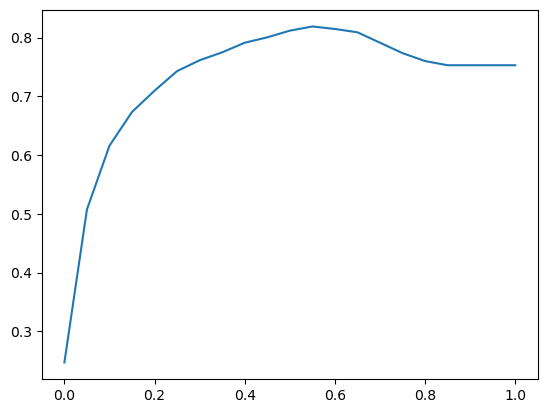

In [67]:
import matplotlib.pyplot as plt

plt.plot(thresholds, scores)
plt.show()

#### Interestingly if we had just put no customer is churning(dummy model), it would've given use 75% accuracy(threshold=1)


## Confusion Table

In [68]:
actual_pos=(y_val==1)
actual_neg=(y_val==0)

In [69]:
pred_pos=(y_val_pred==1)
pred_neg=(y_val_pred==0)

In [70]:
true_pos=(actual_pos & pred_pos).sum()
true_neg=(actual_neg&pred_neg).sum()
true_pos,true_neg

(np.int64(209), np.int64(923))

In [71]:
false_pos=(pred_pos&actual_neg).sum()
false_neg=(pred_neg&actual_pos).sum()
false_pos,false_neg

(np.int64(100), np.int64(177))

In [72]:
confusion_matrix=np.array([
    [true_neg,false_pos],
    [false_neg,true_pos]
])
confusion_matrix

array([[923, 100],
       [177, 209]])

In [73]:
(confusion_matrix/confusion_matrix.sum()).round(3)

array([[0.655, 0.071],
       [0.126, 0.148]])

## Precision and Recall

#### Precision: Fraction of positive predictions that are correct

In [74]:
precision=(true_pos)/(true_pos+false_pos)
precision

np.float64(0.6763754045307443)

#### Recall: Fraction of correctly identified positive examples

In [75]:
recall=(true_pos)/(true_pos+false_neg)
recall

np.float64(0.5414507772020726)

In [76]:
#Accuary is misleading

## ROC curves

### TPR and FPR

In [77]:
tpr=(true_pos)/(true_pos+false_neg)
tpr

np.float64(0.5414507772020726)

In [78]:
fpr=(false_pos)/(false_pos+true_neg)
fpr

np.float64(0.09775171065493646)

In [79]:
thresholds=np.linspace(0,1,101)
scores=[]
for c in thresholds:
    actual_positive=(y_val==1)
    actual_negative=(y_val==0)

    predict_positive=(y_val_prob>=c)
    predict_negative=(y_val_prob<c)
    tp=(predict_positive&actual_positive).sum()
    fp=(actual_negative&predict_positive).sum()
    tn=(actual_negative&predict_negative).sum()
    fn=(actual_positive&predict_negative).sum()
    scores.append((c,tp,fp,fn,tn))

In [80]:
columns=['threshold','tp','fp','fn','tn']
df_scores=pd.DataFrame(scores,columns=columns)
df_scores

,threshold,tp,fp,fn,tn
0,0.00,386,1023,0,0
1,0.01,386,1020,0,3
2,0.02,386,924,0,99
3,0.03,383,841,3,182
4,0.04,383,786,3,237
...,...,...,...,...,...
96,0.96,0,0,386,1023
97,0.97,0,0,386,1023
98,0.98,0,0,386,1023
99,0.99,0,0,386,1023


In [81]:
df_scores['tpr']=(df_scores.tp)/(df_scores.tp+df_scores.fn)
df_scores['fpr']=(df_scores.fp)/(df_scores.fp+df_scores.tn)

In [82]:
df_scores

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,386,1020,0,3,1.000000,0.997067
2,0.02,386,924,0,99,1.000000,0.903226
3,0.03,383,841,3,182,0.992228,0.822092
4,0.04,383,786,3,237,0.992228,0.768328
...,...,...,...,...,...,...,...
96,0.96,0,0,386,1023,0.000000,0.000000
97,0.97,0,0,386,1023,0.000000,0.000000
98,0.98,0,0,386,1023,0.000000,0.000000
99,0.99,0,0,386,1023,0.000000,0.000000


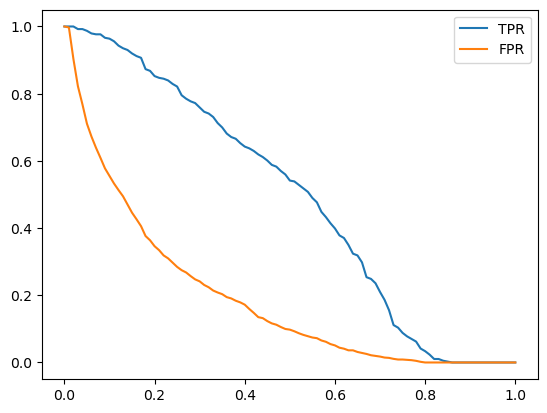

In [83]:
plt.plot(df_scores.threshold,df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold,df_scores['fpr'], label='FPR')
plt.legend()

### Random Model

In [84]:
np.random.seed(1)
y_rand=np.random.uniform(0,1,size=len(y_val))

In [85]:
((y_rand>=.5)==y_val).mean()

np.float64(0.5017743080198722)

In [86]:
def tpr_fpr_dataframe(y_val,y_pred):
    thresholds=np.linspace(0,1,101)
    scores=[]
    for c in thresholds:
        actual_positive=(y_val==1)
        actual_negative=(y_val==0)
    
        predict_positive=(y_pred>=c)
        predict_negative=(y_pred<c)
        tp=(predict_positive&actual_positive).sum()
        fp=(actual_negative&predict_positive).sum()
        tn=(actual_negative&predict_negative).sum()
        fn=(actual_positive&predict_negative).sum()
        scores.append((c,tp,fp,fn,tn))
    columns=['threshold','tp','fp','fn','tn']
    df_scores=pd.DataFrame(scores,columns=columns)
    df_scores['tpr']=(df_scores.tp)/(df_scores.tp+df_scores.fn)
    df_scores['fpr']=(df_scores.fp)/(df_scores.fp+df_scores.tn)
    return df_scores

In [87]:
df_rand=tpr_fpr_dataframe(y_val,y_rand)
df_rand

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,382,1013,4,10,0.989637,0.990225
2,0.02,379,993,7,30,0.981865,0.970674
3,0.03,375,979,11,44,0.971503,0.956989
4,0.04,372,969,14,54,0.963731,0.947214
...,...,...,...,...,...,...,...
96,0.96,14,41,372,982,0.036269,0.040078
97,0.97,11,36,375,987,0.028497,0.035191
98,0.98,8,19,378,1004,0.020725,0.018573
99,0.99,6,7,380,1016,0.015544,0.006843


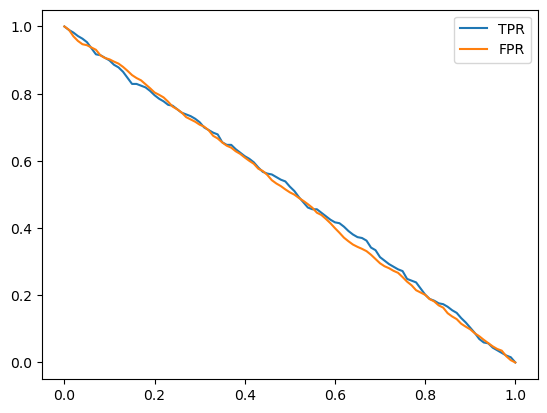

In [88]:
plt.plot(df_rand.threshold,df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold,df_rand['fpr'], label='FPR')
plt.legend()

## Ideal Model

Sorts the customers from not churn to churn(0 to 1 sorting)

In [89]:
num_neg=(y_val==0).sum()
num_pos=(y_val==1).sum()
num_neg,num_pos

(np.int64(1023), np.int64(386))

In [90]:
y_ideal=np.repeat([0,1],[num_neg,num_pos])#repeats 0 num_neg times and repeats 1 num_pos times
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [91]:
y_ideal_prob=np.linspace(0,1,len(y_val))

In [92]:
perfectThreshold=1-y_val.mean()
perfectThreshold

np.float64(0.7260468417317246)

In [93]:
((y_ideal_prob>=0.726)==y_ideal).mean()

np.float64(1.0)

In [94]:
df_ideal=tpr_fpr_dataframe(y_ideal,y_ideal_prob)

In [95]:
df_ideal

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,386,1008,0,15,1.000000,0.985337
2,0.02,386,994,0,29,1.000000,0.971652
3,0.03,386,980,0,43,1.000000,0.957967
4,0.04,386,966,0,57,1.000000,0.944282
...,...,...,...,...,...,...,...
96,0.96,57,0,329,1023,0.147668,0.000000
97,0.97,43,0,343,1023,0.111399,0.000000
98,0.98,29,0,357,1023,0.075130,0.000000
99,0.99,15,0,371,1023,0.038860,0.000000


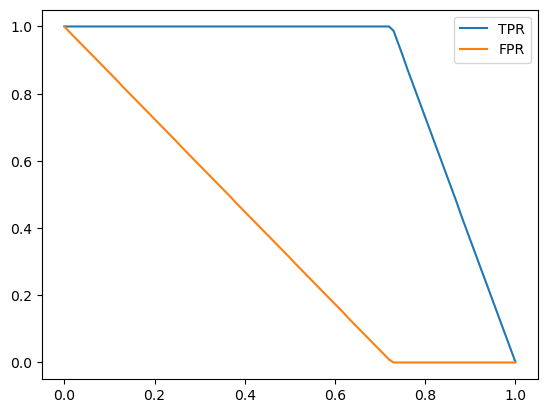

In [96]:
plt.plot(df_ideal.threshold,df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold,df_ideal['fpr'], label='FPR')
plt.legend()

## Putting everything together

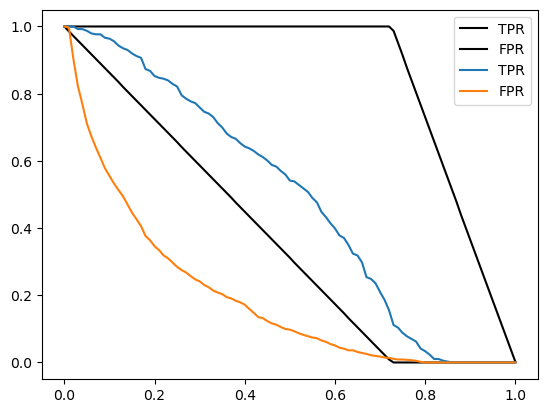

In [97]:
plt.plot(df_ideal.threshold,df_ideal['tpr'], label='TPR', color='black')
plt.plot(df_ideal.threshold,df_ideal['fpr'], label='FPR', color='black')

plt.plot(df_scores.threshold,df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold,df_scores['fpr'], label='FPR')
plt.legend()

### ROC

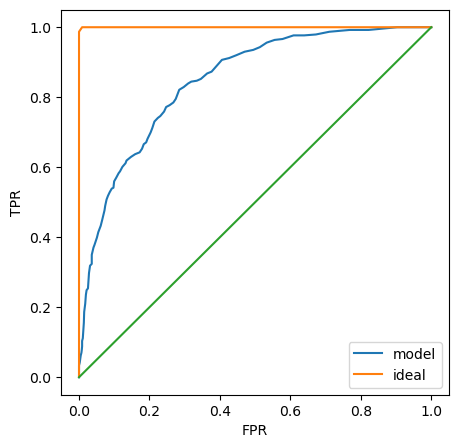

In [98]:
#ROC Curve
plt.figure(figsize=(5,5))
plt.plot(df_scores.fpr,df_scores.tpr,label='model')
plt.plot(df_ideal.fpr,df_ideal.tpr,label='ideal')
plt.plot([0,1],[0,1])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

## ROC Using scikit learn

In [99]:
from sklearn.metrics import roc_curve 

In [100]:
fpr,tpr,thresholds=roc_curve(y_val,y_val_prob)

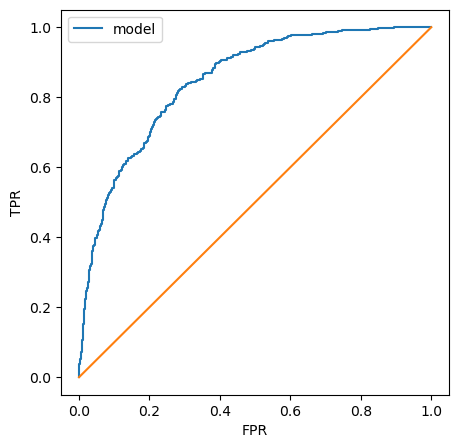

In [101]:
plt.figure(figsize=(5,5))
plt.plot(fpr,tpr,label='model')
plt.plot([0,1],[0,1])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

## ROC AUC(Area Under Curve):

In [102]:
from sklearn.metrics import auc

In [103]:
auc(fpr,tpr)

0.8466893572191917

In [104]:
## Shortcut

In [105]:
from sklearn.metrics import roc_auc_score

In [106]:
roc_auc_score(y_val,y_val_prob)

0.8466893572191917

- AUC= probability that a randomly selected positive example has higher score than randomly selected negative example

In [107]:
import pickle

expected_columns = list(df_full_train2.columns) 

# Package your model parameters, scaling factors, and columns
model_data = {
    'w': w,
    'b': b,
    'mean': mean,
    'std': std,
    'columns': expected_columns
}

# Save the trained model
pickle_model_path = "churn_model.pkl"
with open(pickle_model_path, "wb") as f:
    pickle.dump(model_data, f)
    
print(f"Model saved successfully to {pickle_model_path}")

Model saved successfully to churn_model.pkl
